In [2]:
## perturbation experiments for dissecting hepg2 and k562 regulatory code 

In [3]:
import os, sys, pickle, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

lib_path = os.path.join(REPO, 'virtual_perturbations', 'libraries', 'hippo_target_library.pkl')
with open(lib_path, 'rb') as f:
    lib = pickle.load(f)

df = lib['df']
focus_tfs = lib['focus_tfs']

# Build EigenMap — HepG2 first so it plots on top
CT = {'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Build seq_idx -> raw npz index mapping (npz has all seq_valid rows,
# df used the additional keep filter dropping 3 rows)
raw = np.load(lib['attr_npz_path'])
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna()
n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
raw_indices = np.arange(n)[keep]  # filtered_idx -> raw npz idx
del df_full

ohe = em.X.numpy()
idxs = df.seq_idx.values
npz_idxs = raw_indices[idxs]  # correct mapping
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]

em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

print(f'Loaded {len(df)} sequences')
print(f'  Conditions: {df["condition"].value_counts().to_dict()}')
print(f'  Focus TFs: {len(focus_tfs)}')
print(f'  Cell type order: {em.cell_types} (top row first)')

AlphaGenome patches applied (all functional activations -> nn.Module).
EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
Loaded 1059 sequences
  Conditions: {'same-diff': 353, 'diff-diff': 353, 'same-same': 353}
  Focus TFs: 151
  Cell type order: ['HepG2', 'K562'] (top row first)


In [ ]:
em.load_expression()
em.rank_motif_hits()

In [4]:
## Select same-diff examples from extremes

# Focus TF families
focus_families = {
    'HNF': ['HNF1A', 'HNF1B', 'HNF4A', 'HNF4G'],
    'STAT': ['STAT1', 'STAT2', 'STAT1::STAT2', 'Stat2', 'Stat5a', 'Stat5b'],
    'AP1': ['JUN', 'Jun', 'JUNB', 'FOS', 'Fosb', 'BATF::JUN'],
    'TEA': ['TEAD1', 'TEAD2', 'TEAD4'],
}
all_focus = set()
for v in focus_families.values():
    all_focus.update(v)

# Same-diff only, sorted by EI_1 var x r (most negative = strongest)
sd = df[df.condition == 'same-diff'].copy()
sd = sd.sort_values('EI_1 var x r')

# Count how many focus families each seq has
def count_families(tfs_str):
    seq_tfs = set(tfs_str.split(','))
    return sum(1 for fam, members in focus_families.items() if seq_tfs & set(members))

def which_families(tfs_str):
    seq_tfs = set(tfs_str.split(','))
    return [fam for fam, members in focus_families.items() if seq_tfs & set(members)]

sd['n_families'] = sd.all_tfs.apply(count_families)
sd['families'] = sd.all_tfs.apply(which_families)
sd['has_focus'] = sd.all_tfs.apply(lambda x: bool(set(x.split(',')) & all_focus))

# Prioritize: most families first, then most extreme score
sd_focus = sd[sd.has_focus].sort_values(['n_families', 'EI_1 var x r'], ascending=[False, True])

print(f'Same-diff sequences with focus TFs: {len(sd_focus)}')
print(f'\nTop candidates (most families, most extreme score):')
for _, row in sd_focus.head(15).iterrows():
    print(f'  seq_idx={row.seq_idx:5d}  EI1_vxr={row["EI_1 var x r"]:.3f}  '
          f'pred_K562={row.pred_K562:.2f}  pred_HepG2={row.pred_HepG2:.2f}  '
          f'families={row.families}  tfs={row.all_tfs}')

Same-diff sequences with focus TFs: 325

Top candidates (most families, most extreme score):
  seq_idx=56709  EI1_vxr=-0.541  pred_K562=-0.76  pred_HepG2=1.30  families=['HNF', 'AP1', 'TEA']  tfs=BATF3,Fosb,HNF1A,HNF1B,RXRB,RXRG,Rxra,TEAD2,USF3
  seq_idx=56710  EI1_vxr=-0.433  pred_K562=-0.35  pred_HepG2=1.77  families=['HNF', 'AP1', 'TEA']  tfs=ATF6,BATF3,CREB3L1,Fosb,HNF1A,HNF1B,ONECUT1,ONECUT3,Ppara,RXRB,RXRG,Rxra,TCF7,TEAD2,USF3,XBP1,ZNF708
  seq_idx=44011  EI1_vxr=-0.586  pred_K562=-0.44  pred_HepG2=0.75  families=['HNF', 'AP1']  tfs=FOS,HNF1A,HNF1B
  seq_idx=53473  EI1_vxr=-0.456  pred_K562=-0.73  pred_HepG2=1.45  families=['HNF', 'TEA']  tfs=HNF1A,HNF1B,MEF2B,Nkx3-1,TEAD2,ZNF146
  seq_idx=38466  EI1_vxr=-0.430  pred_K562=-0.57  pred_HepG2=3.87  families=['HNF', 'TEA']  tfs=EWSR1-FLI1,Elf5,FOXB1,FOXC1,FOXH1,GATA2,GATA4,GATA6,HNF1A,HNF1B,HOXD12::ELK1,IKZF2,TCF7,TCF7L1,TCF7L2,TEAD1,ZBTB47,ZKSCAN4,ZNF367,ZNF680,ZNF8,Zic2
  seq_idx=56734  EI1_vxr=-0.404  pred_K562=-0.73  pred_HepG2=1

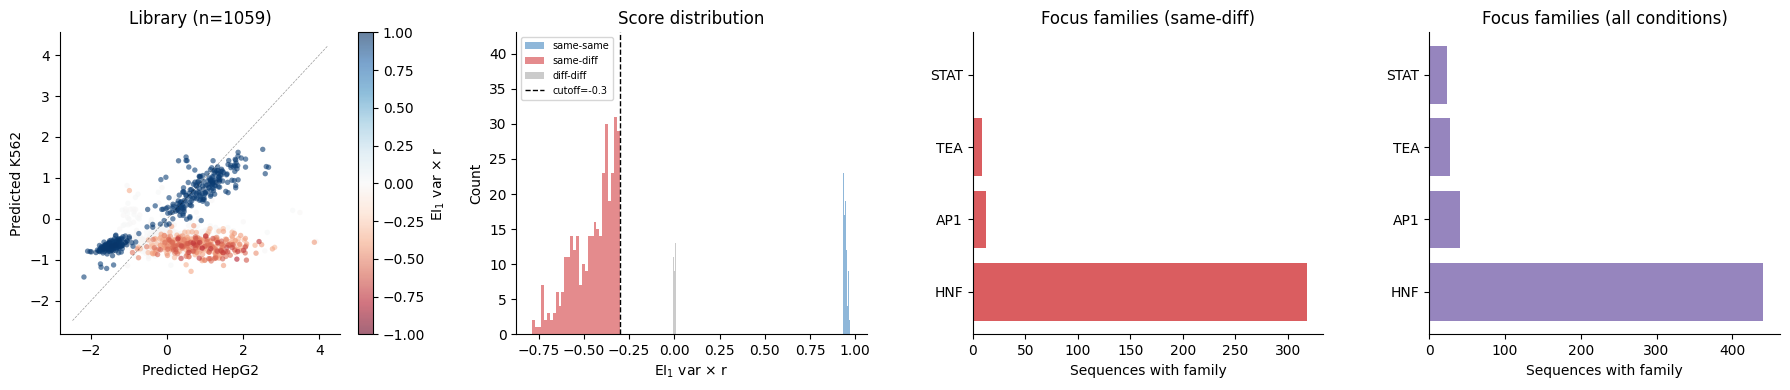

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1) HepG2 vs K562 predictions colored by EI_1 var x r
order = np.argsort(np.abs(df['EI_1 var x r'].values))
sc = axes[0].scatter(df.pred_HepG2.values[order], df.pred_K562.values[order],
                     s=15, alpha=0.6, c=df['EI_1 var x r'].values[order],
                     cmap='RdBu', vmin=-1, vmax=1, edgecolors='none')
lims = [df[['pred_HepG2','pred_K562']].min().min()-0.3, df[['pred_HepG2','pred_K562']].max().max()+0.3]
axes[0].plot(lims, lims, 'k--', lw=0.5, alpha=0.4)
axes[0].set_xlabel('Predicted HepG2'); axes[0].set_ylabel('Predicted K562')
plt.colorbar(sc, ax=axes[0], label='EI$_1$ var $\\times$ r')
axes[0].set_title(f'Library (n={len(df)})')

# 2) EI_1 var x r distribution by condition
cmap_d = {'same-same': '#2171b5', 'same-diff': '#cb181d', 'diff-diff': '#999999'}
for cond in ['same-same', 'same-diff', 'diff-diff']:
    vals = df.loc[df.condition == cond, 'EI_1 var x r']
    axes[1].hist(vals, bins=30, alpha=0.5, color=cmap_d[cond], label=cond)
axes[1].axvline(lib['ei_cutoff'], color='k', ls='--', lw=1, label=f'cutoff={lib["ei_cutoff"]}')
axes[1].set_xlabel('EI$_1$ var $\\times$ r'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=7); axes[1].set_title('Score distribution')

# 3) Focus family counts in same-diff
fam_counts = Counter()
for fams in sd_focus.families:
    fam_counts.update(fams)
fams_sorted = sorted(fam_counts, key=fam_counts.get, reverse=True)
axes[2].barh(fams_sorted, [fam_counts[f] for f in fams_sorted], color='#cb181d', alpha=0.7)
axes[2].set_xlabel('Sequences with family'); axes[2].set_title('Focus families (same-diff)')

# 4) Focus family counts across entire library
fam_counts_all = Counter()
for _, row in df.iterrows():
    seq_tfs = set(row.all_tfs.split(','))
    for fam, members in focus_families.items():
        if seq_tfs & set(members):
            fam_counts_all[fam] += 1
fams_sorted_all = sorted(fam_counts_all, key=fam_counts_all.get, reverse=True)
axes[3].barh(fams_sorted_all, [fam_counts_all[f] for f in fams_sorted_all], color='#6a51a3', alpha=0.7)
axes[3].set_xlabel('Sequences with family'); axes[3].set_title('Focus families (all conditions)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

same-diff | seq_idx=56772  EI1_vxr=-0.785
  pred_HepG2=1.84  pred_K562=-0.98
  TFs: BCL6B,HMBOX1,HNF1A,HNF1B,POU6F1,SOX10,ZNF286B


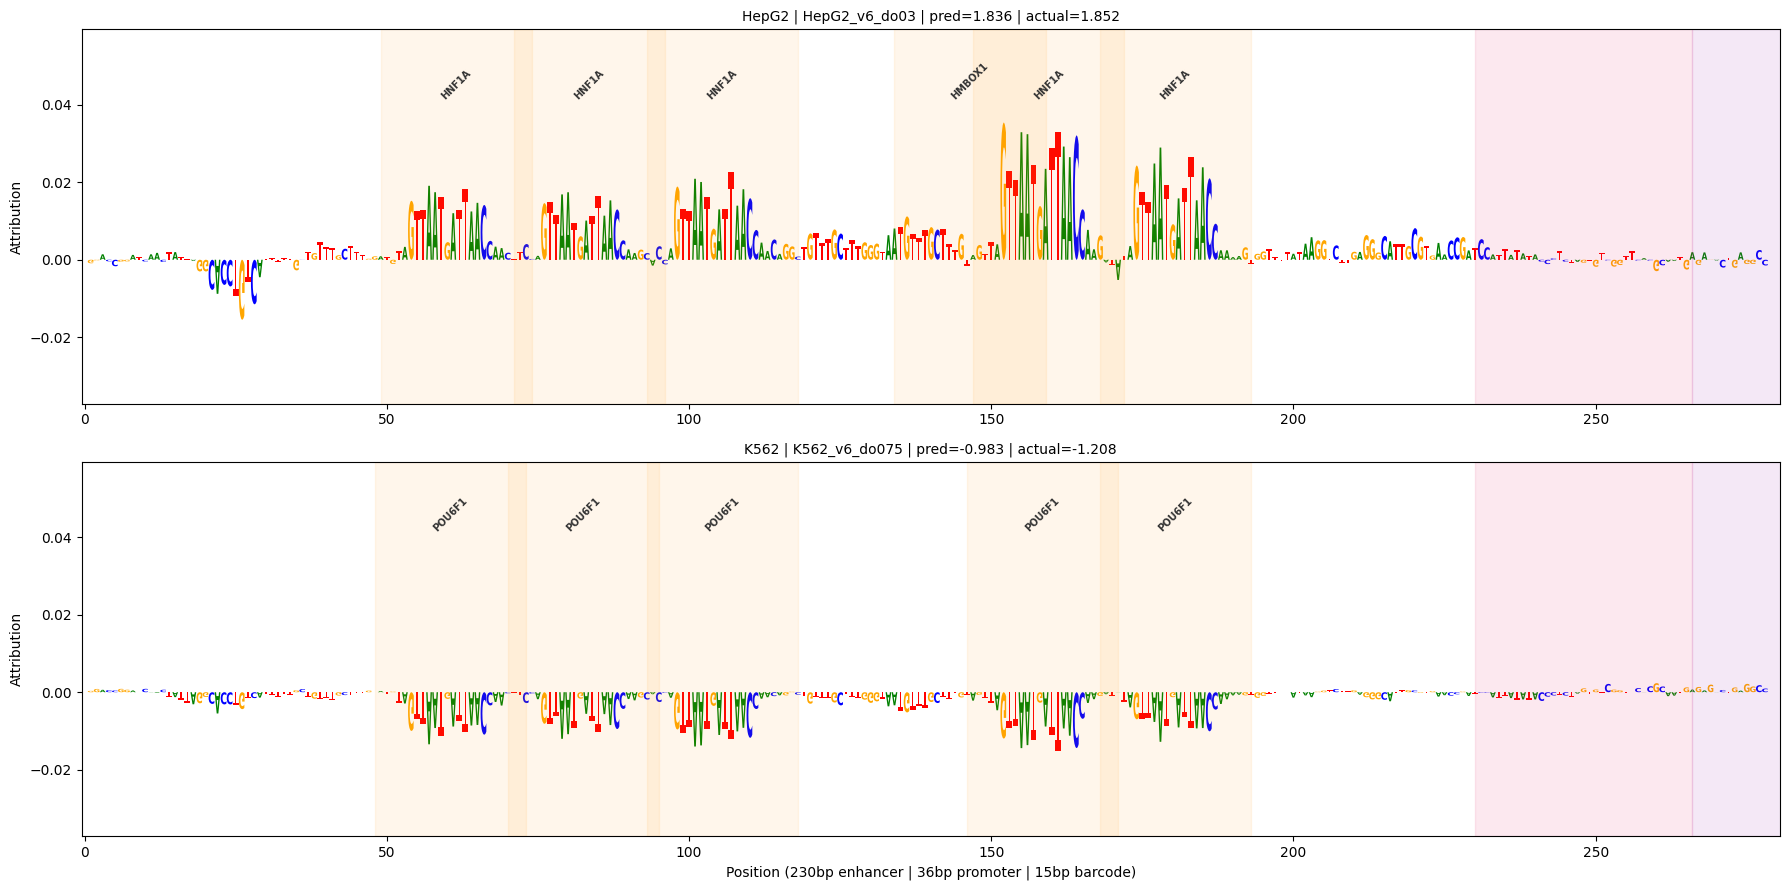

In [6]:
## same-diff: most negative EI_1 var x r

idx = df[df.condition == 'same-diff']['EI_1 var x r'].idxmin()
row = df.loc[idx]
local_idx = df.index.get_loc(idx)

print(f'same-diff | seq_idx={row.seq_idx}  EI1_vxr={row["EI_1 var x r"]:.3f}')
print(f'  pred_HepG2={row.pred_HepG2:.2f}  pred_K562={row.pred_K562:.2f}')
print(f'  TFs: {row.all_tfs}')

em.plot_attr_logos_with_motifs(seq_idx=local_idx)

plt.savefig('../results/HNF1A-POU6F1.png', dpi=300, bbox_inches='tight')                                                                       

same-same | seq_idx=53997  EI1_vxr=0.977
  pred_HepG2=-1.26  pred_K562=-0.53
  TFs: Hoxd13,MAFF,NRL,Nr2F6,REST,Rarb,ZNF410,ZNF449,ZNF493


(<Figure size 1800x900 with 2 Axes>,
 array([<Axes: title={'center': 'HepG2 | HepG2_v6_do03 | pred=-1.259 | actual=-0.918'}, ylabel='Attribution'>,
        <Axes: title={'center': 'K562 | K562_v6_do075 | pred=-0.526 | actual=-0.878'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)', ylabel='Attribution'>],
       dtype=object))

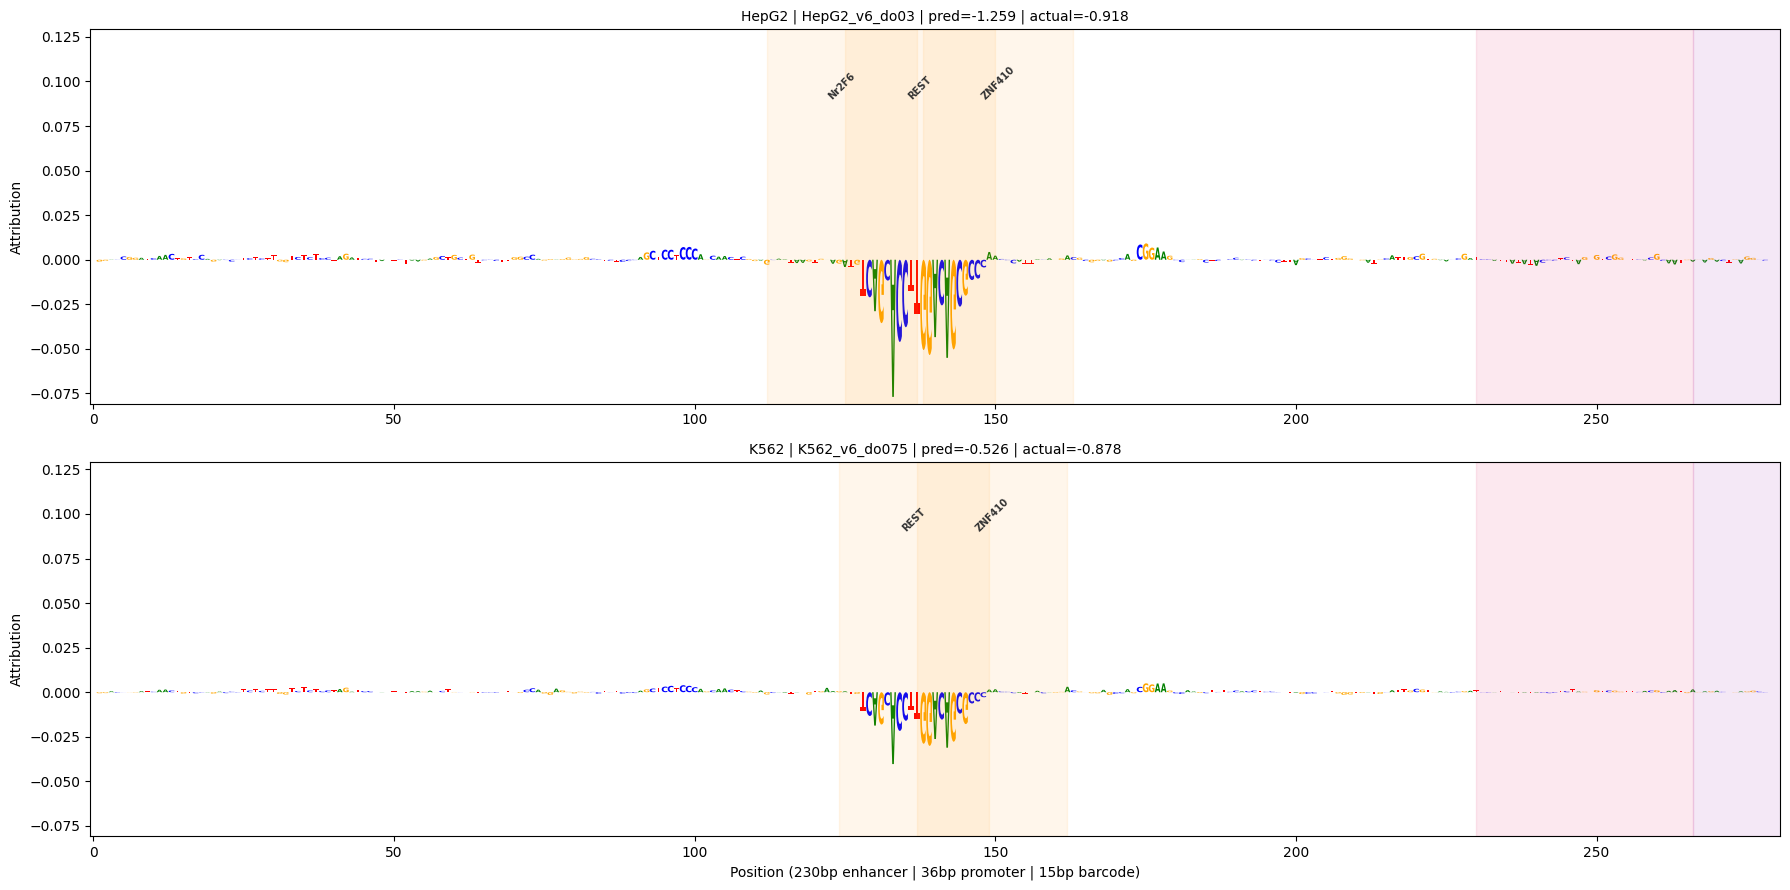

In [7]:
## same-same: most positive EI_1 var x r

idx = df[df.condition == 'same-same']['EI_1 var x r'].idxmax()
row = df.loc[idx]
local_idx = df.index.get_loc(idx)

print(f'same-same | seq_idx={row.seq_idx}  EI1_vxr={row["EI_1 var x r"]:.3f}')
print(f'  pred_HepG2={row.pred_HepG2:.2f}  pred_K562={row.pred_K562:.2f}')
print(f'  TFs: {row.all_tfs}')

em.plot_attr_logos_with_motifs(seq_idx=local_idx)

diff-diff | seq_idx=26012  EI1_vxr=-0.000
  pred_HepG2=-0.96  pred_K562=0.24
  TFs: GATA2,GATA4,GATA6,TRPS1


(<Figure size 1800x900 with 2 Axes>,
 array([<Axes: title={'center': 'HepG2 | HepG2_v6_do03 | pred=-0.963 | actual=-0.812'}, ylabel='Attribution'>,
        <Axes: title={'center': 'K562 | K562_v6_do075 | pred=0.237 | actual=0.146'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)', ylabel='Attribution'>],
       dtype=object))

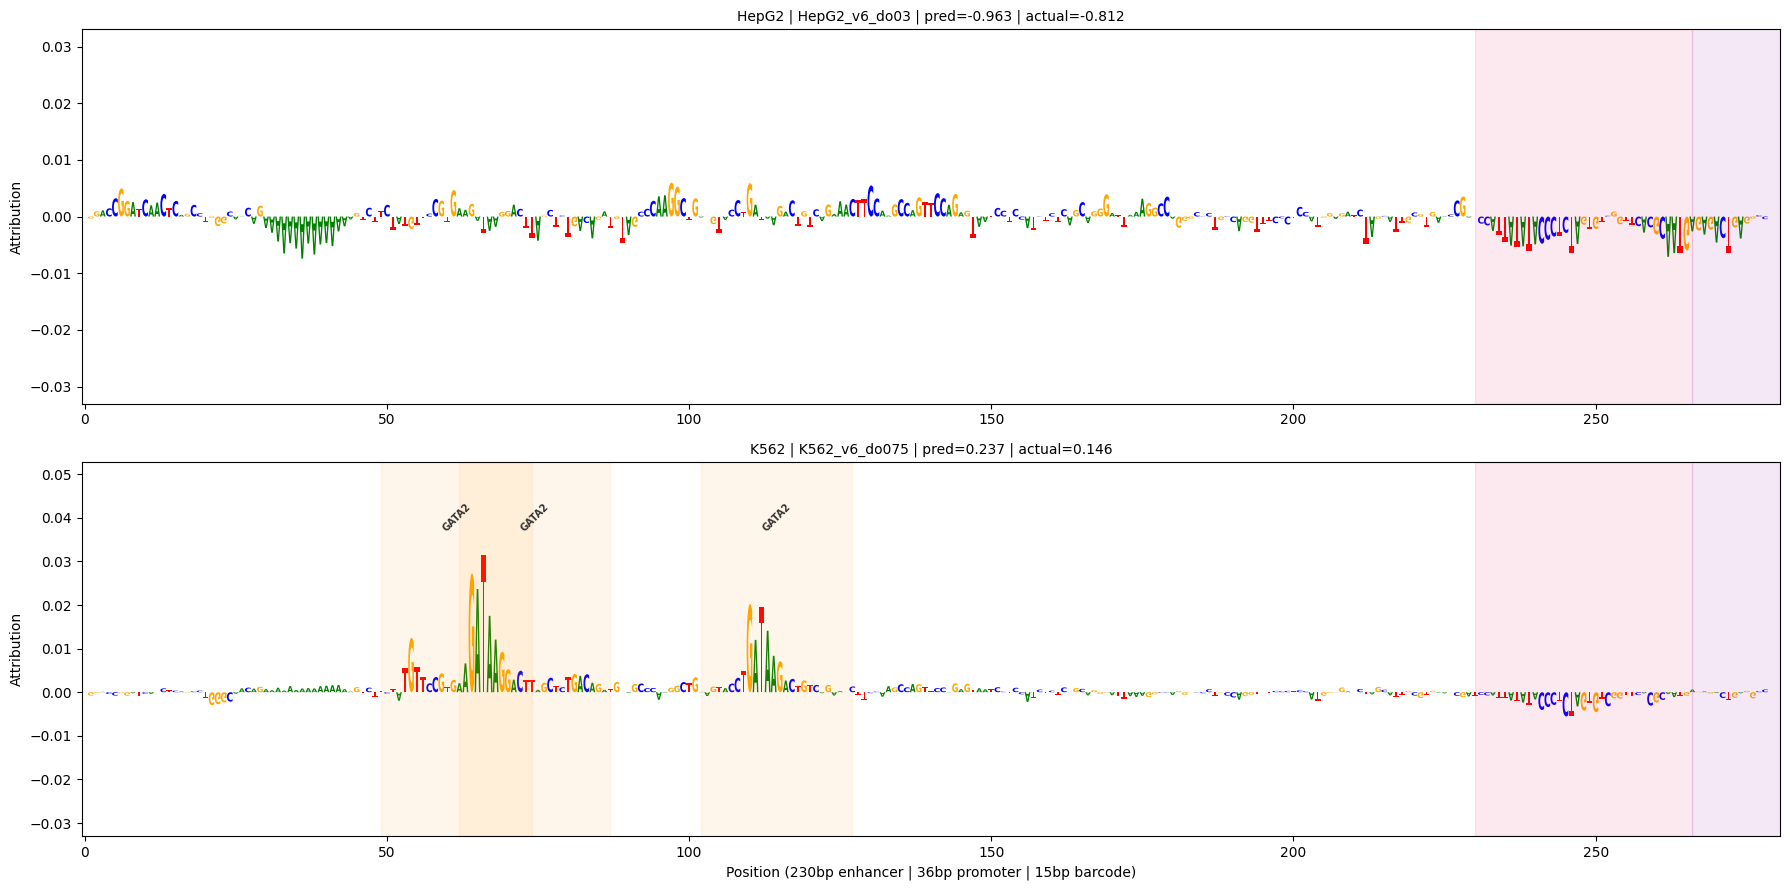

In [8]:
## diff-diff: random seq near EI_1 var x r ~ 0

dd = df[df.condition == 'diff-diff']
near_zero = dd.iloc[(dd['EI_1 var x r'].abs()).argsort().values[0]]
idx = near_zero.name
local_idx = df.index.get_loc(idx)

print(f'diff-diff | seq_idx={near_zero.seq_idx}  EI1_vxr={near_zero["EI_1 var x r"]:.3f}')
print(f'  pred_HepG2={near_zero.pred_HepG2:.2f}  pred_K562={near_zero.pred_K562:.2f}')
print(f'  TFs: {near_zero.all_tfs}')

em.plot_attr_logos_with_motifs(seq_idx=local_idx)